###   Titanic dataset EDA

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

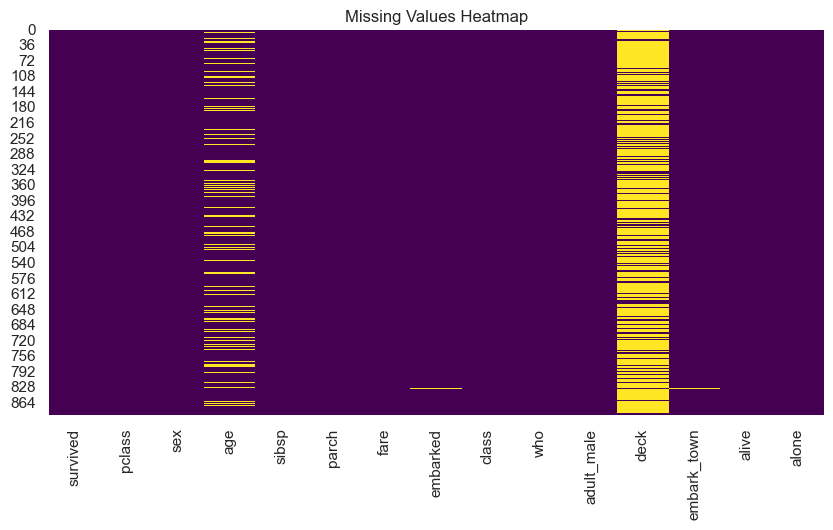

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


C:\Users\hriti\AppData\Local\Temp\ipykernel_14724\2827064092.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\hriti\AppData\Local\Temp\ipykernel_14724\2827064092.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

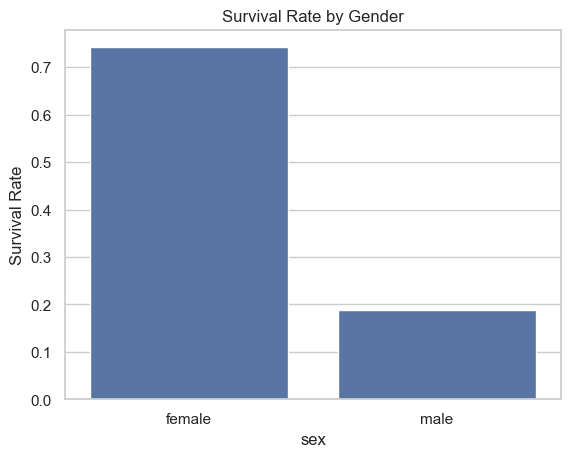

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


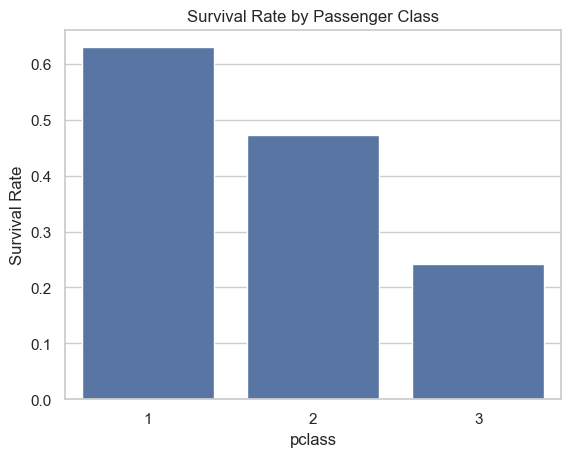

age_group
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: survived, dtype: float64


C:\Users\hriti\AppData\Local\Temp\ipykernel_14724\2827064092.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_age = df.groupby('age_group')['survived'].mean()


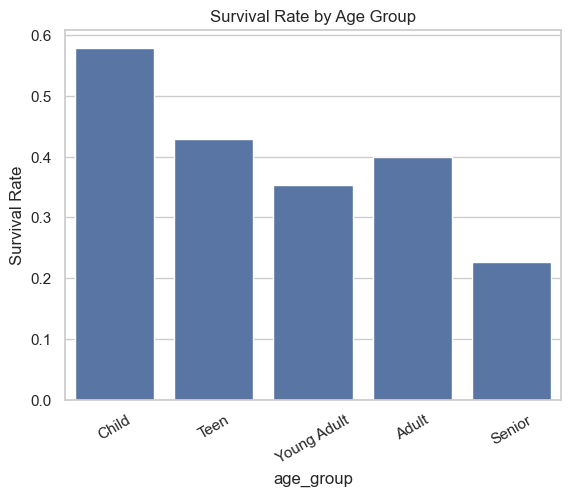

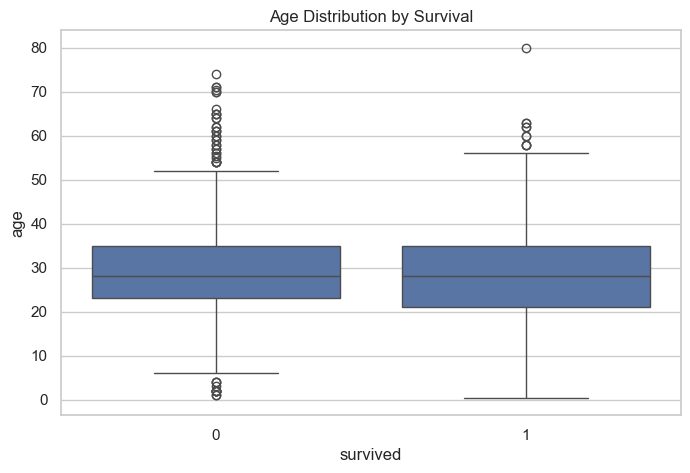

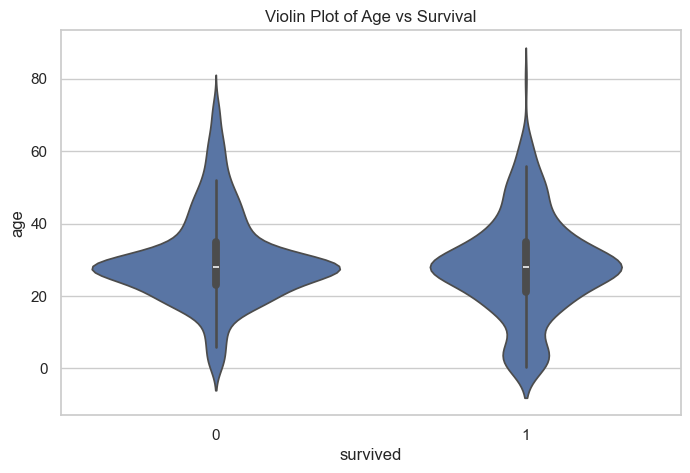

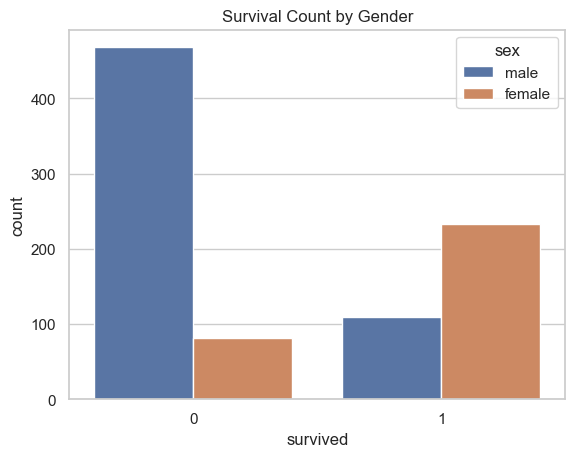

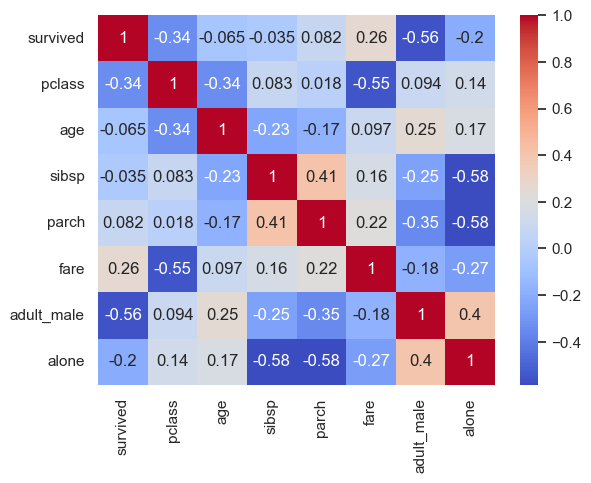

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = sns.load_dataset("titanic")

print(df.head())
print(df.info())
print(df.describe())

print("\nMissing Values:\n", df.isnull().sum())

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

df['age'].fillna(df['age'].median(), inplace=True)

if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

survival_sex = df.groupby('sex')['survived'].mean()
print(survival_sex)

sns.barplot(x=survival_sex.index, y=survival_sex.values)
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

survival_class = df.groupby('pclass')['survived'].mean()
print(survival_class)

sns.barplot(x=survival_class.index, y=survival_class.values)
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

survival_age = df.groupby('age_group')['survived'].mean()
print(survival_age)

sns.barplot(x=survival_age.index, y=survival_age.values)
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='survived', y='age', data=df)
plt.title("Age Distribution by Survival")
plt.show()

plt.figure(figsize=(8,5))
sns.violinplot(x='survived', y='age', data=df)
plt.title("Violin Plot of Age vs Survival")
plt.show()

sns.countplot(x='survived', hue='sex', data=df)
plt.title("Survival Count by Gender")
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()
